
## Classification

In this project, we will classify mushrooms as being edible or poisonous depending on different features. Logistic regression, linear discriminant analysis and quadratic discriminant analysis will be used.

The data set contains 8124 rows and the following features:

class: edible(e) or poisonous(p)

cap-shape: bell(b), conical(c), convex(x), flat(f), knobbed(k), sunken(s)

cap-surface: fibrous(f), grooves(g), scaly(y), smooth(s)

cap-color: brown(n), buff(b), cinnamon(c), gray(g), green(r), pink(p), purple(u), red(e), white(w), yellow(y)

bruises: bruises(t), no bruises(f)

odor: almond(a), anise(l), creosote(c), fishy(y), foul(f), musty(m), none(n), pungent(p), spicy(s)

gill-attachment: attached(a), descending(d), free(f), notched(n)

gill-spacing: close(c), crowded(w), distant(d)

gill-size: broad(b), narrow(n)

gill-color: black(k), brown(n), buff(b), chocolate(h), gray(g), green(r), orange(o), pink(p), purple(u), red(e), white(w), yellow(y)

stalk-shape: enlarging(e), tapering(t)

stalk-root: bulbous(b), club(c), cup(u), equal(e), rhizomorphs(z), rooted(r), missing(?)

stalk-surface-above-ring: fibrous(f), scaly(y), silky(k), smooth(s)

stalk-surface-below-ring: fibrous(f), scaly(y), silky(k), smooth(s)

stalk-color-above-ring: brown(n), buff(b), cinnamon(c), gray(g), orange(o), pink(p), red(e), white(w), yellow(y)

stalk-color-below-ring: brown(n), buff(b), cinnamon(c), gray(g), orange(o), pink(p), red(e), white(w), yellow(y)

veil-type: partial(p), universal(u)

veil-color: brown(n), orange(o), white(w), yellow(y)

ring-number: none(n), one(o), two(t)

ring-type: cobwebby(c), evanescent(e), flaring(f), large(l), none(n), pendant(p), sheathing(s), zone(z)

spore-print-color: black(k), brown(n), buff(b), chocolate(h), green(r), orange(o), purple(u), white(w), yellow(y)

population: abundant(a), clustered(c), numerous(n), scattered(s), several(v), solitary(y)

habitat: grasses(g), leaves(l), meadows(m), paths(p), urban(u), waste(w), woods(d)


In [21]:
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc

%matplotlib inline

In [3]:
DATAPATH = "../data/mushrooms.csv"

data = pd.read_csv(DATAPATH)

data.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


/var/folders/k2/5tk_ss4d4dg4clx_xl1r7ffm0000gn/T/ipykernel_5693/3626666919.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=x, data=data, palette='Set2')


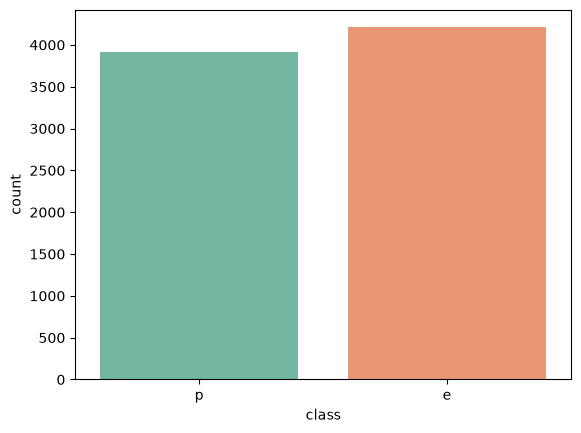

In [5]:
x = data['class']

ax = sns.countplot(x=x, data=data, palette='Set2') 


In [6]:
def plot_data(hue, data, palette='Set2'):
    for i, col in enumerate(data.columns):
        plt.figure(figsize=(10, 5))
        sns.countplot(x=col, hue=hue, data=data, palette=palette)
        plt.title(f'Count of {col} by {hue}')
        plt.show()

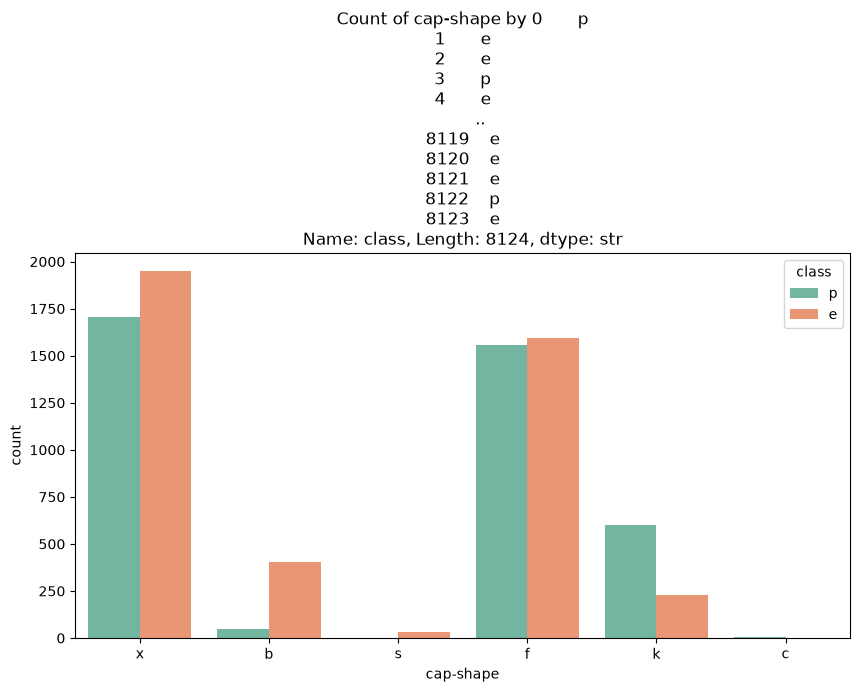

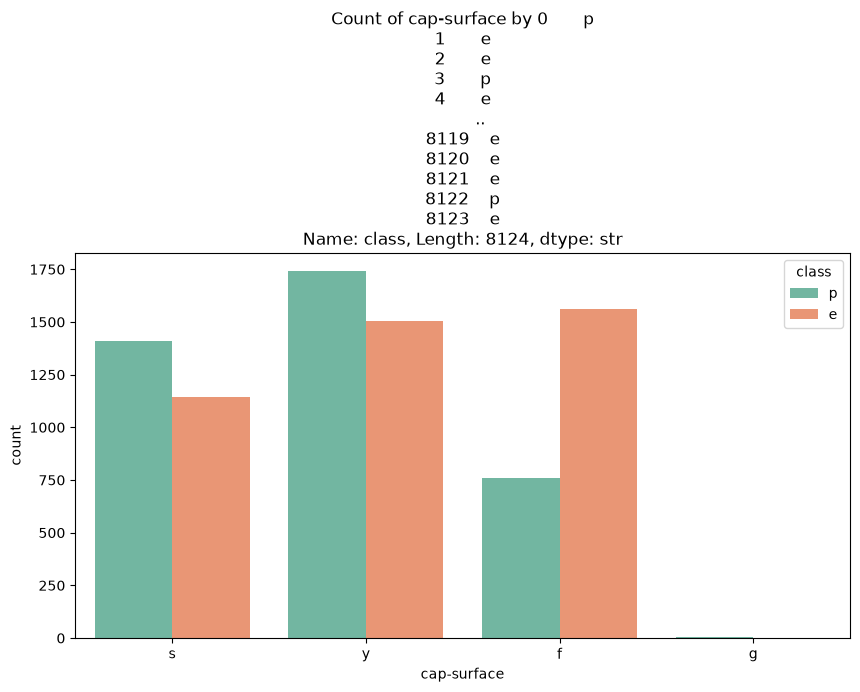

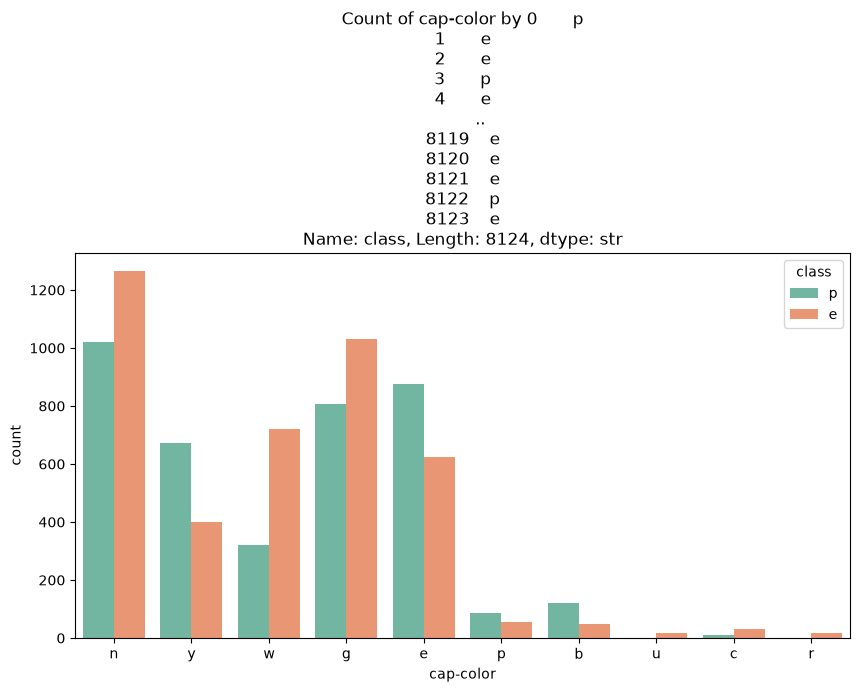

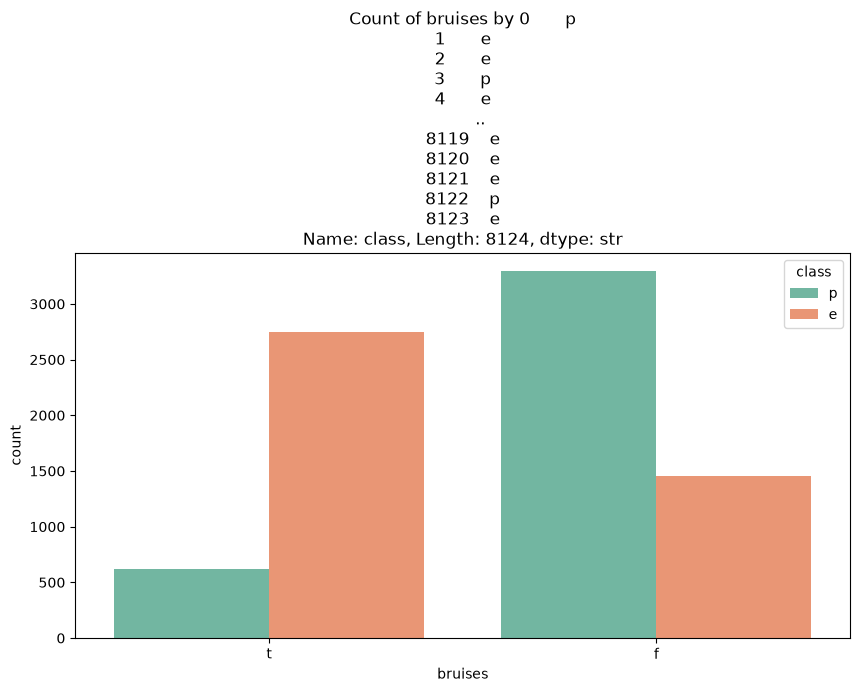

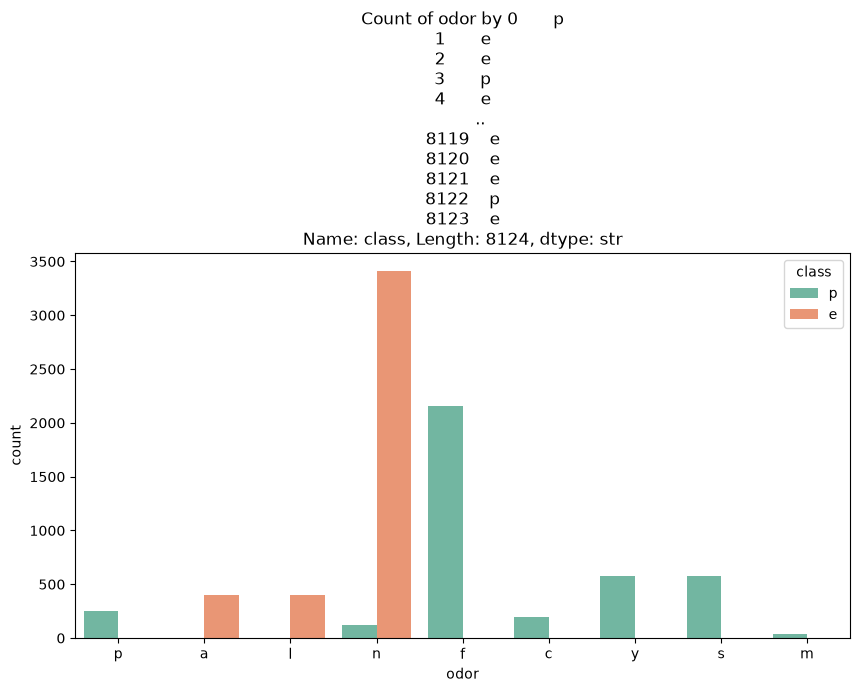

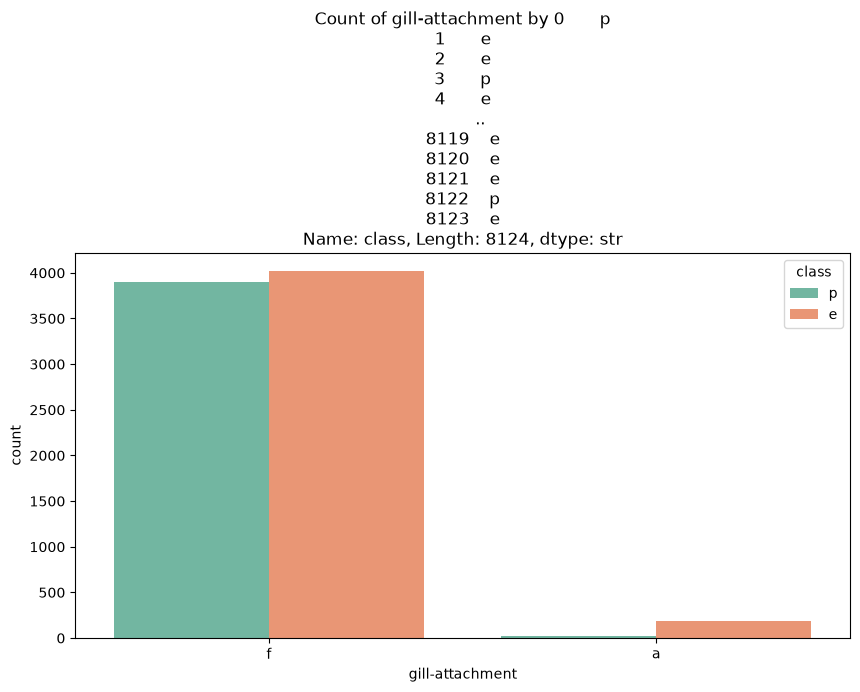

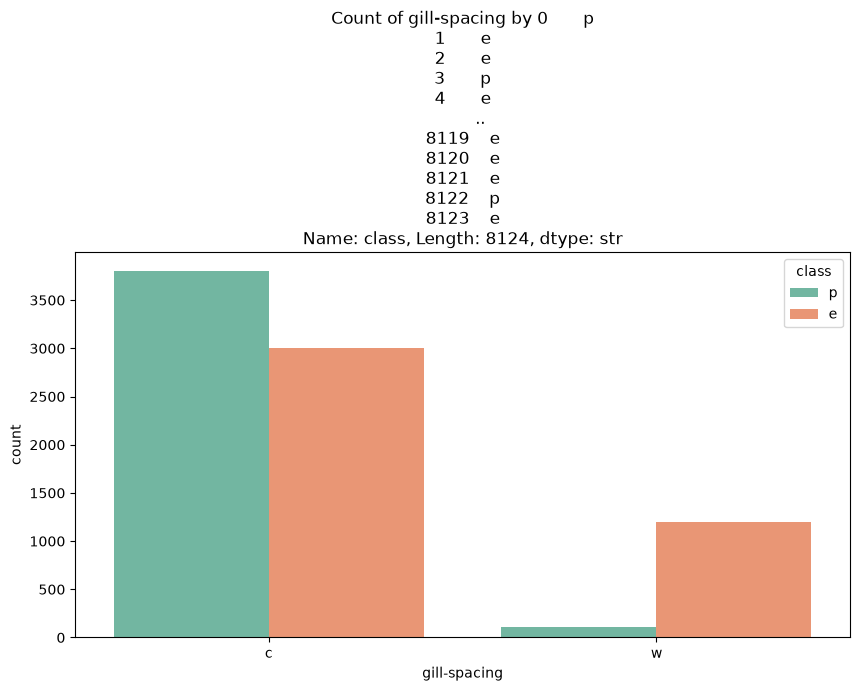

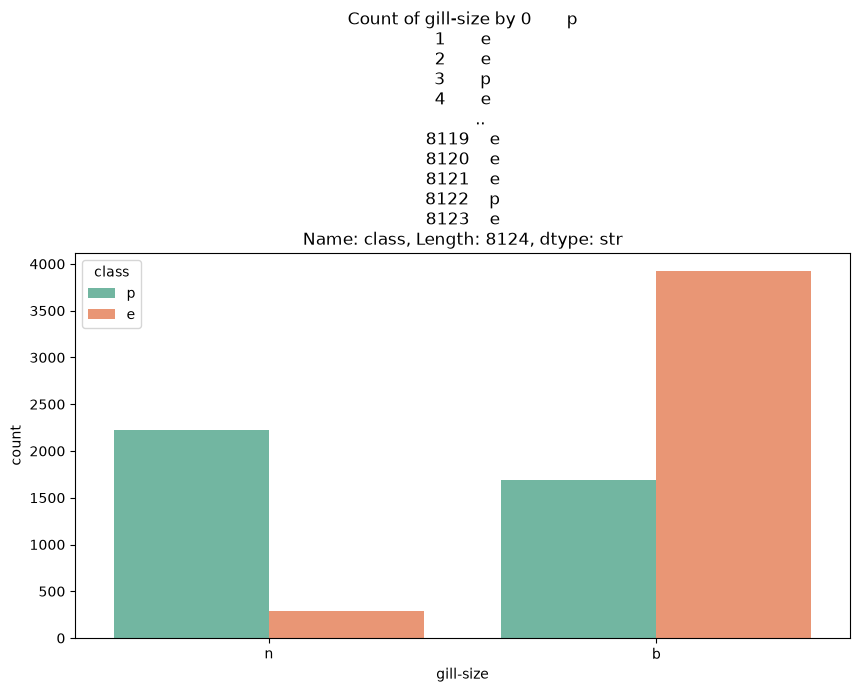

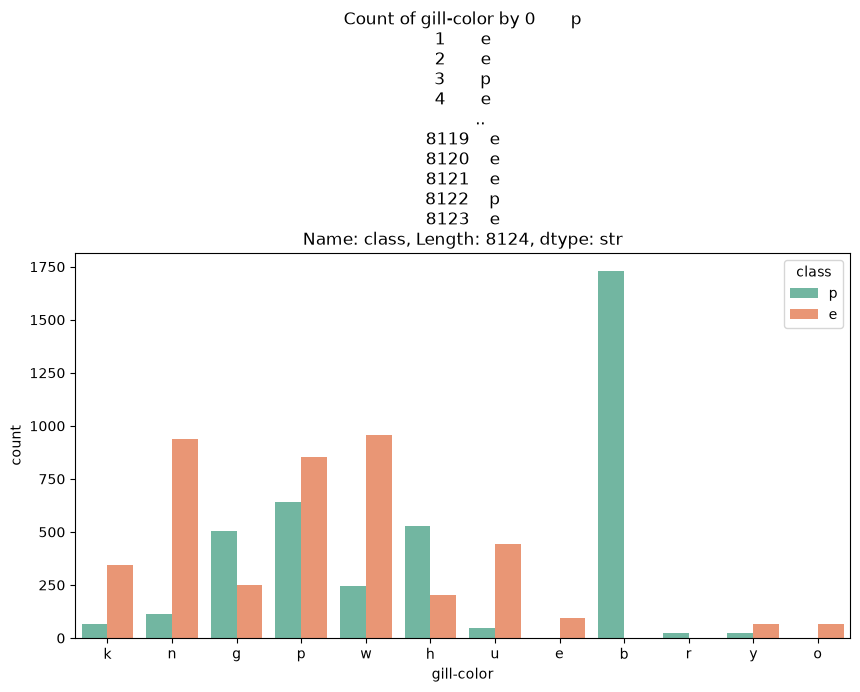

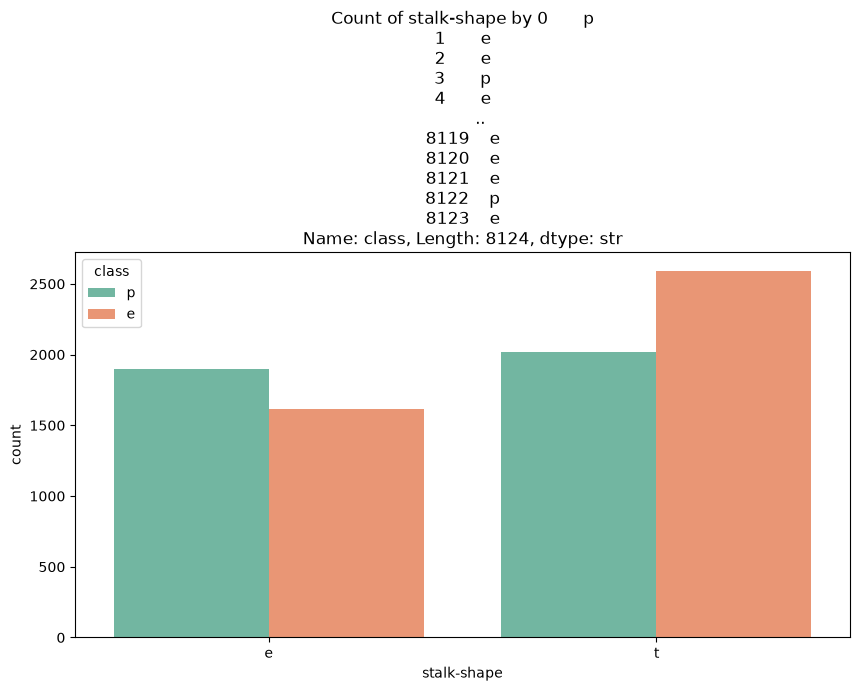

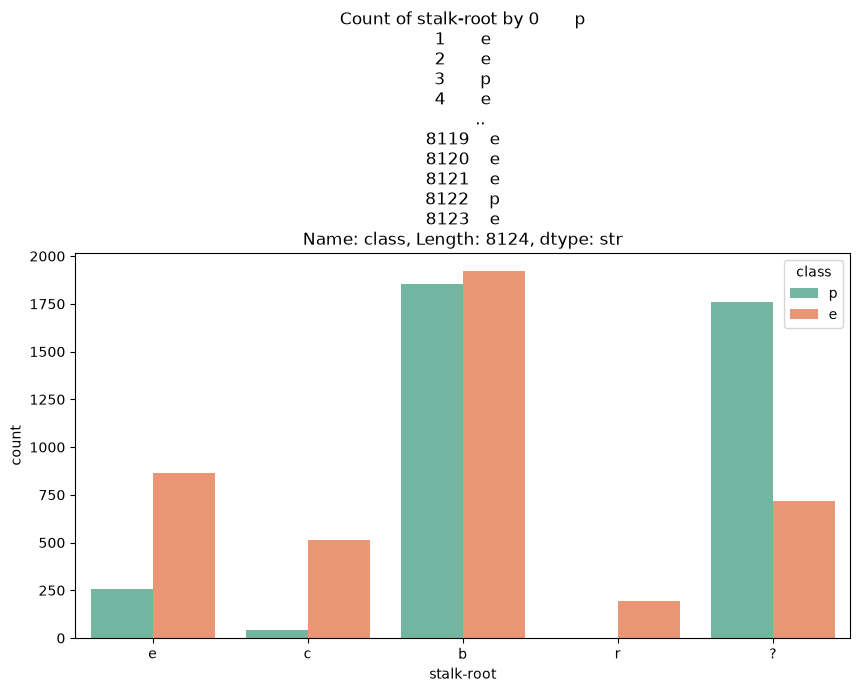

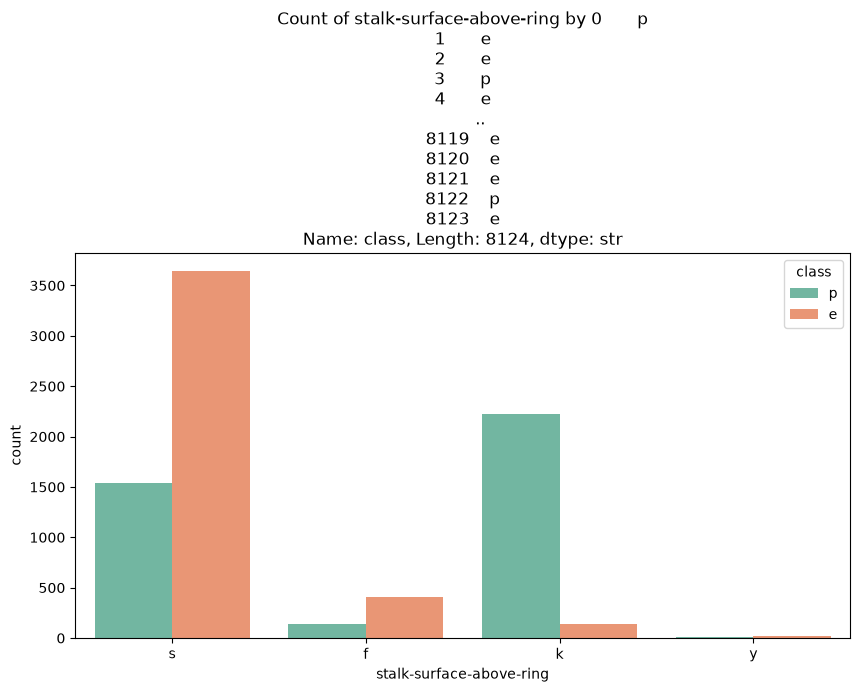

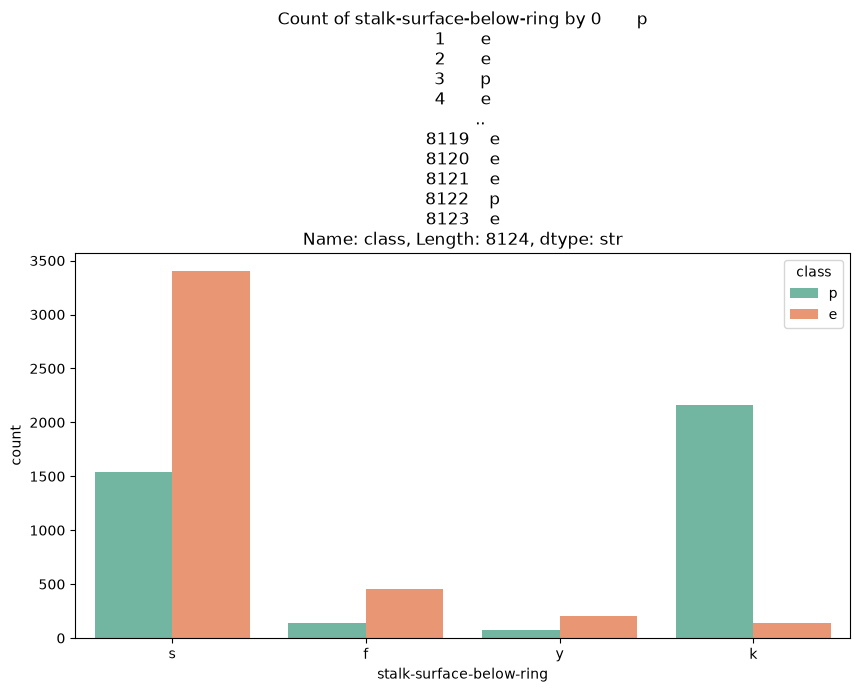

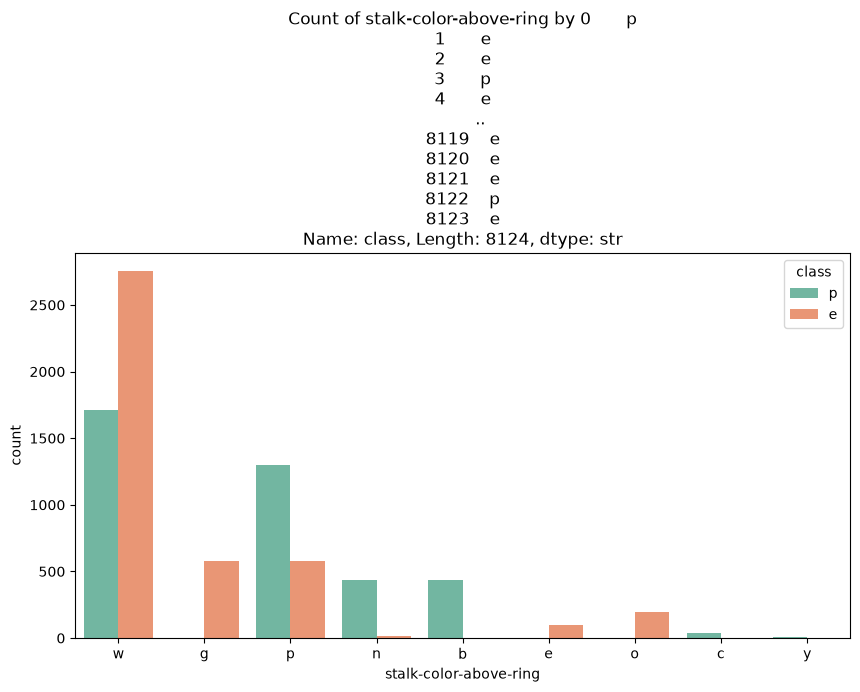

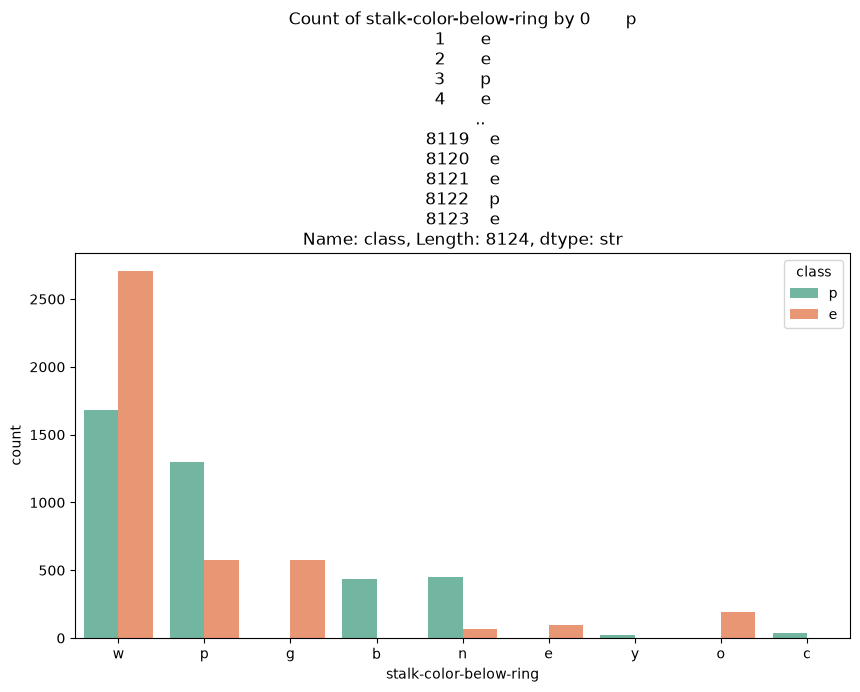

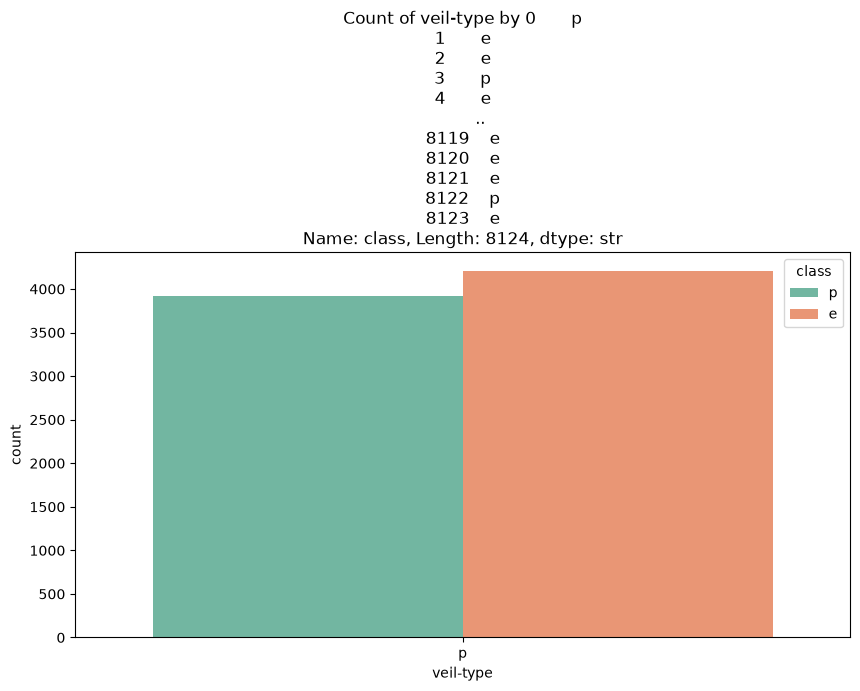

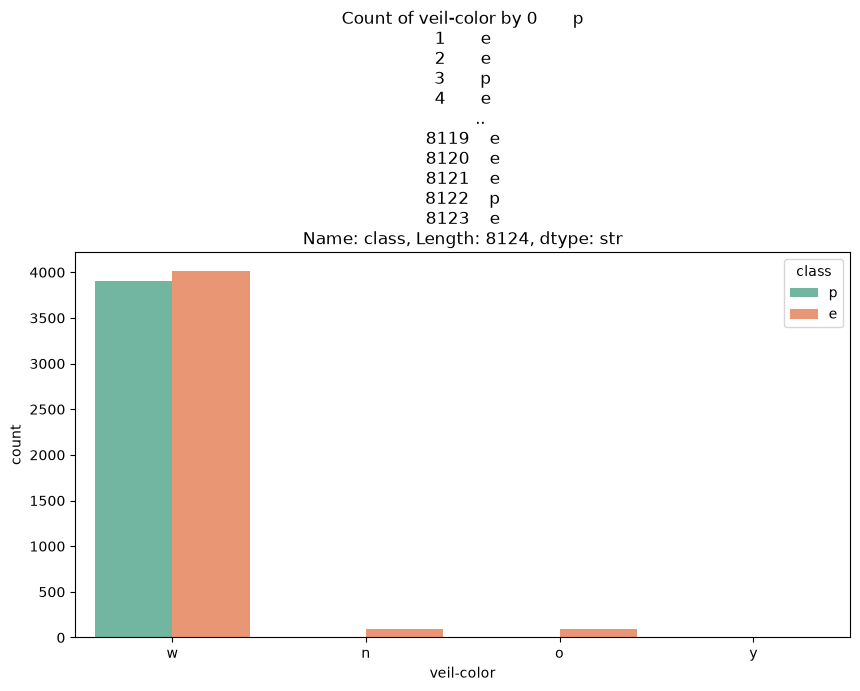

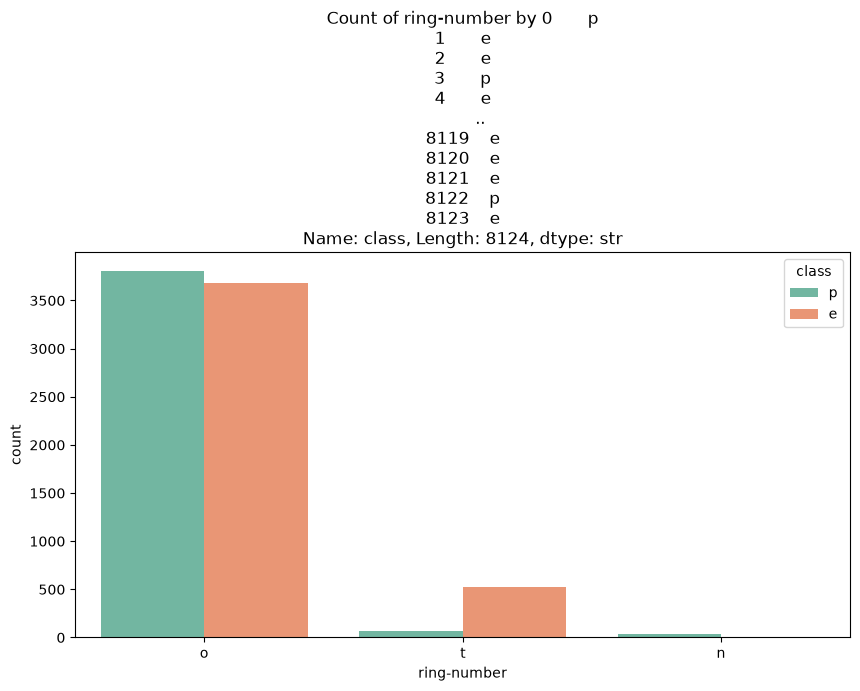

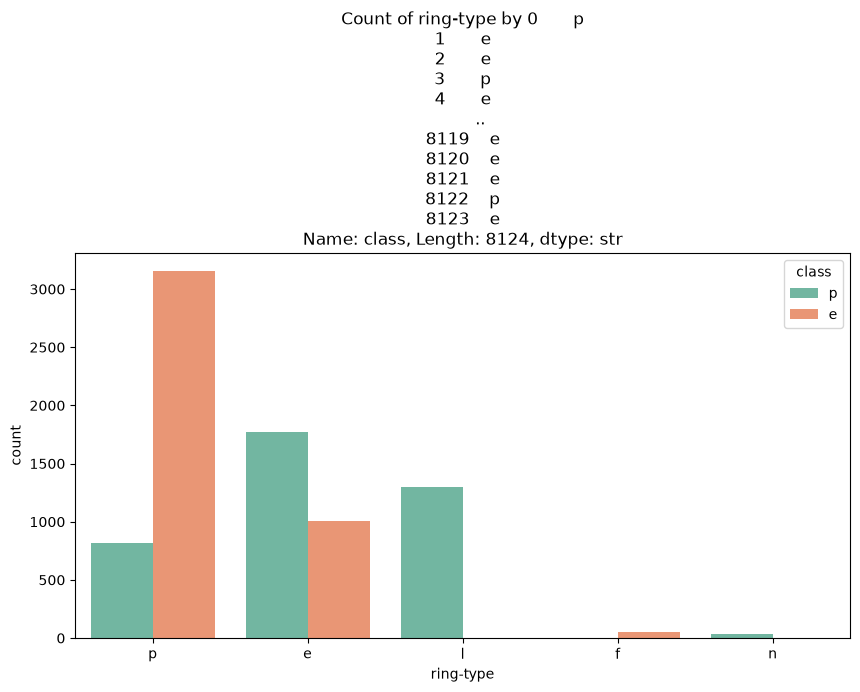

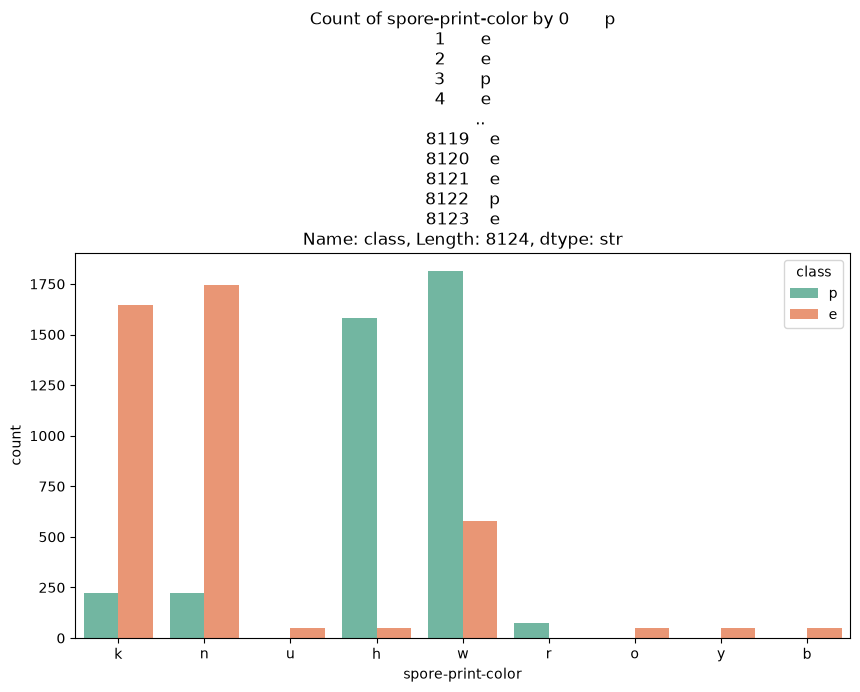

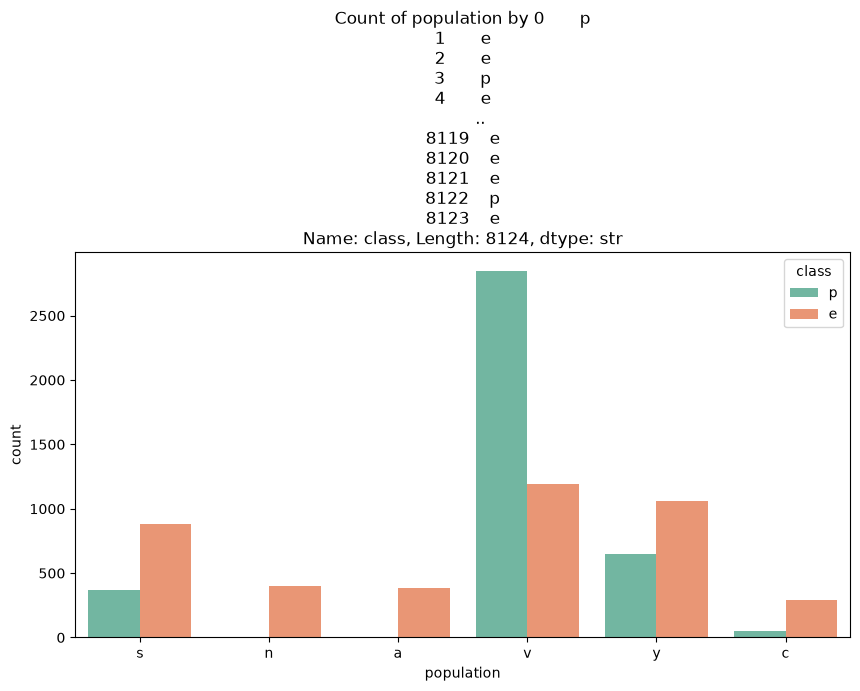

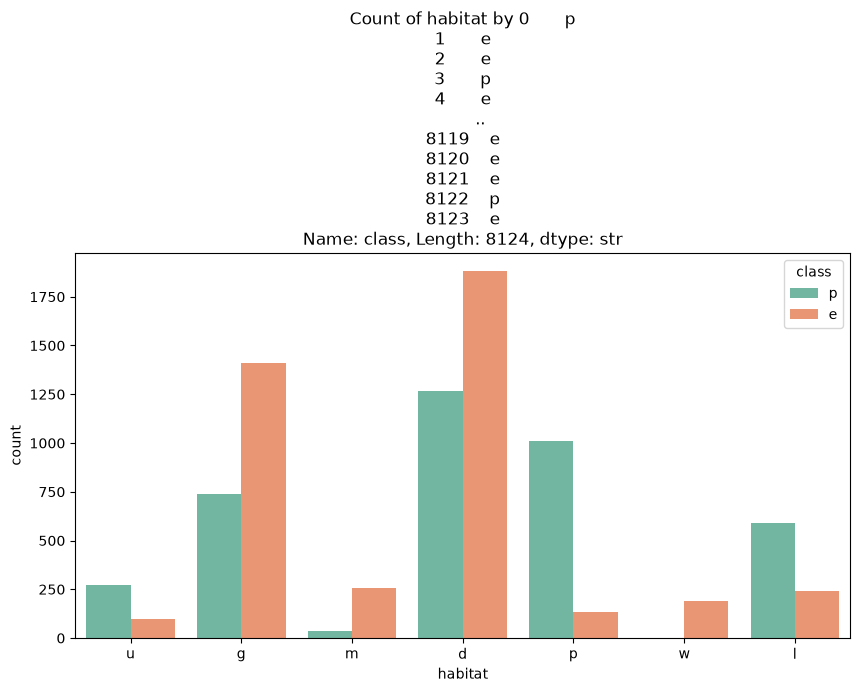

In [7]:
hue = data['class']
data_to_plot = data.drop(columns=['class'])

plot_data(hue, data_to_plot)

In [8]:
for col in data.columns:
    print(f"Column: {col}")
    print(data[col].value_counts())
    print("\n")
    print(f"Column: {col}")

Column: class
class
e    4208
p    3916
Name: count, dtype: int64


Column: class
Column: cap-shape
cap-shape
x    3656
f    3152
k     828
b     452
s      32
c       4
Name: count, dtype: int64


Column: cap-shape
Column: cap-surface
cap-surface
y    3244
s    2556
f    2320
g       4
Name: count, dtype: int64


Column: cap-surface
Column: cap-color
cap-color
n    2284
g    1840
e    1500
y    1072
w    1040
b     168
p     144
c      44
u      16
r      16
Name: count, dtype: int64


Column: cap-color
Column: bruises
bruises
f    4748
t    3376
Name: count, dtype: int64


Column: bruises
Column: odor
odor
n    3528
f    2160
y     576
s     576
a     400
l     400
p     256
c     192
m      36
Name: count, dtype: int64


Column: odor
Column: gill-attachment
gill-attachment
f    7914
a     210
Name: count, dtype: int64


Column: gill-attachment
Column: gill-spacing
gill-spacing
c    6812
w    1312
Name: count, dtype: int64


Column: gill-spacing
Column: gill-size
gill-size
b    5612


In [9]:
le = LabelEncoder()

data['class'] = le.fit_transform(data['class'])

data.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,0,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,0,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,1,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,0,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [10]:
encoded_data = pd.get_dummies(data)
encoded_data.head()

,class,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,1,False,False,False,False,False,True,False,False,True,...,True,False,False,False,False,False,False,False,True,False
1,0,False,False,False,False,False,True,False,False,True,...,False,False,False,False,True,False,False,False,False,False
2,0,True,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
3,1,False,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,True,False
4,0,False,False,False,False,False,True,False,False,True,...,False,False,False,False,True,False,False,False,False,False


In [11]:
encoded_data = encoded_data.astype(int)

encoded_data.head()

,class,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,1,0,0,0,0,0,1,0,0,1,...,1,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
3,1,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,0


In [12]:
y = encoded_data['class'].values.reshape(-1, 1)
x = encoded_data.drop(columns=['class']).values



In [13]:
x, y

(array([[0, 0, 0, ..., 0, 1, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [1, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 1, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(8124, 117)),
 array([[1],
        [0],
        [0],
        ...,
        [0],
        [1],
        [0]], shape=(8124, 1)))

In [14]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


Logistic Regression

In [16]:
from sklearn.linear_model import LogisticRegression

# init the model 
logreg = LogisticRegression()

# train 
logreg.fit(X_train, y_train.ravel())

# make a prediction 
y_prob = logreg.predict_proba(X_test)[:, 1]

y_pred = np.where(y_prob > 0.5, 1, 0)


In [17]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm 

array([[843,   0],
       [  0, 782]])

In [22]:
#
false_positive_rate, true_positive_rate, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(false_positive_rate, true_positive_rate)

In [23]:
roc_auc

1.0

In [28]:
def plot_roc_curve(fpr, tpr, roc_auc):
    plt.figure(figsize=(10, 5))
    plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

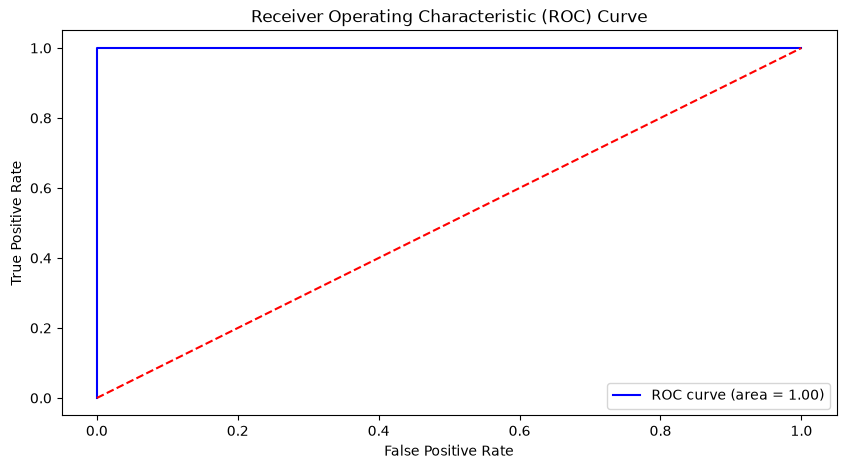

In [29]:
plot_roc_curve(false_positive_rate, true_positive_rate, roc_auc)

In [30]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis()

lda.fit(X_train, y_train.ravel())

y_pred_lda = lda.predict_proba(X_test)[:, 1]
y_pred_lda = np.where(y_pred_lda > 0.5, 1, 0)



In [31]:
# confusion matrix 

cm_lda = confusion_matrix(y_test, y_pred_lda)
print("Confusion Matrix - LDA:")
cm_lda

Confusion Matrix - LDA:


array([[843,   0],
       [  0, 782]])

In [32]:
# build the roc curve for LDA 
false_positive_rate_lda, true_positive_rate_lda, thresholds_lda = roc_curve(y_test, y_pred_lda)

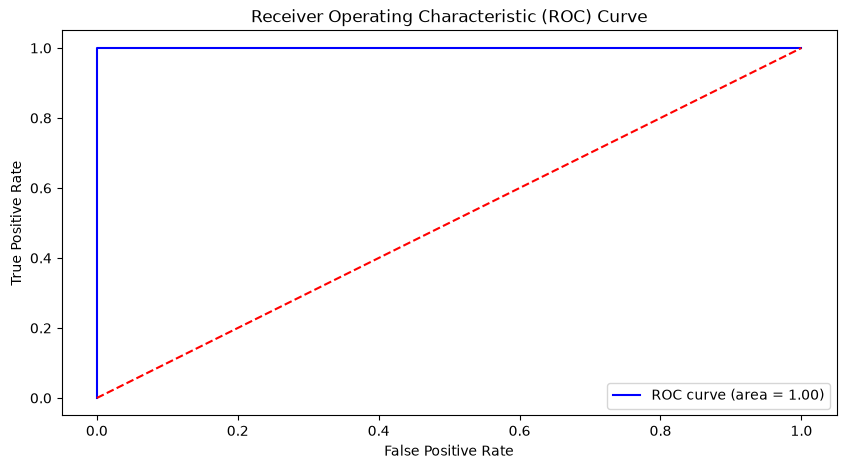

In [33]:
plot_roc_curve(false_positive_rate_lda, true_positive_rate_lda, auc(false_positive_rate_lda, true_positive_rate_lda))

# QDA 

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()

qda = QuadraticDiscriminantAnalysis(reg_param=0.1)
qda.fit(X_train, y_train.ravel())

y_proba_qda = qda.predict_proba(X_test)[:, 1]
y_pred_qda = np.where(y_proba_qda > 0.5, 1, 0)


LinAlgError: The covariance matrix of class 0 is not full rank. Increase the value of `reg_param` to reduce the collinearity.